In [158]:
import numpy as np
import pandas as pd
import seaborn as sns

In [159]:
df = pd.read_csv('titanic.csv')

In [160]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

uselesss column passengerid can be removed and removing Ticket feature for now and ignoring cabin

In [161]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

In [162]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
318,1,1,female,31.0,0,2,164.8667,S
229,0,3,female,NaN,3,1,25.4667,S
358,1,3,female,NaN,0,0,7.8792,Q
199,0,2,female,24.0,0,0,13.0000,S
261,1,3,male,3.0,4,2,31.3875,S


Numerical - Age, Fare  
Categorical - Survived, Pclass, Sex, SibSp, Parch, Embarked

# Feature Scaling for Numerical Features

## Age

<Axes: xlabel='Age'>

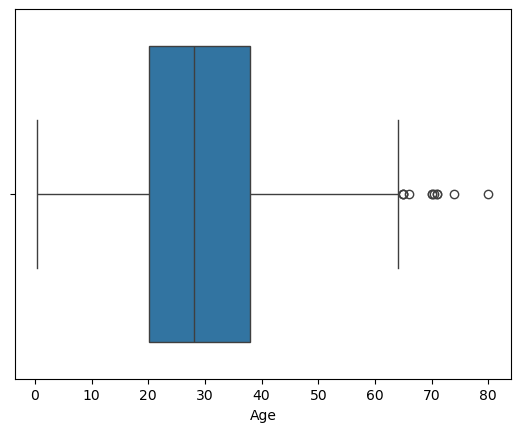

In [163]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='Fare'>

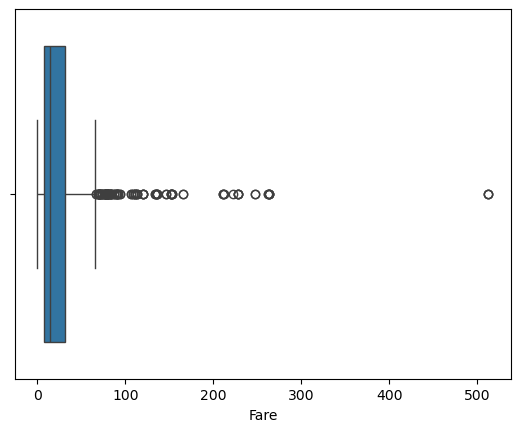

In [164]:
sns.boxplot(x=df['Fare'])

In [165]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [166]:
(df['Fare']>31).sum()

np.int64(222)

In [167]:
(df['Fare']<31).sum()

np.int64(666)

too many outliers in fare -> so robust scaling  
and let's apply standard scaler to Age

In [168]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

### Standardisation of Age

In [169]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived', axis = 1), df['Survived'], test_size = 0.3, random_state = 0)

In [170]:
# get age columns and fare columns for feature scaling
X_train_age = X_train[['Age']]
X_test_age = X_test[['Age']]

X_train_fare = X_train[['Fare']]
X_test_fare = X_test[['Fare']]

In [171]:
X_train_age.isnull().sum()

Age    121
dtype: int64

In [172]:
#standard scale for age

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

std_scaler.fit(X_train_age)

X_train_age_scaled = std_scaler.transform(X_train_age)
X_test_age_scaled = std_scaler.transform(X_test_age)

In [173]:
X_train_age_scaled = pd.DataFrame(X_train_age_scaled, columns = X_train_age.columns)
X_test_age_scaled = pd.DataFrame(X_test_age_scaled, columns = X_test_age.columns)

In [174]:
X_train_age_scaled.isnull().sum()

Age    121
dtype: int64

In [175]:
X_train_age.isnull().sum()

Age    121
dtype: int64

### Robust scaler for Fare

In [176]:
from sklearn.preprocessing import RobustScaler

robust = RobustScaler()
robust.fit(X_train_fare)

X_train_fare_scaled = robust.transform(X_train_fare)
X_test_fare_scaled = robust.transform(X_test_fare)

In [177]:
X_train_fare_scaled = pd.DataFrame(X_train_fare_scaled, columns = X_train_fare.columns)
X_test_fare_scaled = pd.DataFrame(X_test_fare_scaled, columns = X_test_fare.columns)

In [184]:
X_train_age_scaled.isnull().sum()


Age    121
dtype: int64

In [185]:
X_train_num = pd.concat([X_train_age_scaled, X_train_fare_scaled], axis=1)

In [187]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


# Categorical Data Handling

Categorical columns to handle - Sex, Embarked

## Ordinal Categories -> Ordinal Encoding

ordinal - Pclass but it's already encoded so no need to handle

so let's get to One Hot encoding of Sex and Embarked

In [219]:
# get age columns and fare columns for feature scaling
X_train_cats = X_train[['Sex', 'Embarked']]
X_test_cats = X_test[['Sex', 'Embarked']]

In [220]:
X_train_cats['Embarked'].value_counts()

Embarked
S    457
C    108
Q     56
Name: count, dtype: int64

In [221]:
X_train_cats.isnull().sum()

Sex         0
Embarked    2
dtype: int64

In [222]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output = False, dtype = np.int32)
X_train_cat = ohe.fit_transform(X_train_cats[['Sex', 'Embarked']])
X_test_cat = ohe.transform(X_test_cats[['Sex', 'Embarked']])

In [240]:
X_train_cats[X_train_cats['Embarked']=='C']

,Sex,Embarked
52,female,C
578,female,C
118,male,C
532,male,C
533,female,C
...,...,...
874,female,C
174,male,C
599,male,C
9,female,C


In [242]:
X_train_cats.iloc[52, :]

Sex         male
Embarked       C
Name: 524, dtype: object

In [243]:
X_train_cat[52]

array([1, 0, 0, 0], dtype=int32)

In [245]:
X_train_cat = pd.DataFrame(X_train_cat, columns = ['Male', 'Nan', 'Q', 'S'])
X_test_cat = pd.DataFrame(X_test_cat, columns = ['Male', 'Nan', 'Q', 'S'])

In [250]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


# Mentos Zindage -> Column Transformer

In [279]:
from sklearn.compose import ColumnTransformer

In [280]:
transformer = ColumnTransformer(transformers=[
    ('tnf1', StandardScaler(), ['Age']),
    ('tnf2', RobustScaler(), ['Fare']),
    ('tnf3', OneHotEncoder(drop='first', sparse_output = False), ['Sex', 'Embarked']),
], remainder = 'passthrough')

In [281]:
X_train_transformed = transformer.fit_transform(X_train)

In [282]:
X_test_transformed = transformer.transform(X_test)

In [285]:
feature_names = transformer.get_feature_names_out()

X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
